<style>
.jp-Notebook .jp-MarkdownCell,
.text_cell_render {
    font-size: 14px;
    line-height: 1.38;
}
.jp-CodeCell .cm-editor,
.jp-CodeCell pre,
.code_cell .CodeMirror {
    font-size: 13px !important;
    line-height: 1.30 !important;
}
</style>

# ECON 422: Macroeconomics & Machine Learning
## Large Language Models

An autoregressive language model predicts the next token:

$$
P_\Theta(w_{t+1}=j\mid w_{1:t})
=
\frac{\exp(u_j)}{\sum_{k=1}^{K}\exp(u_k)}.
$$

For the observed next token, the cross-entropy loss is

$$
L(\Theta)=-\log P_\Theta(w_{t+1}\mid w_{1:t}),
$$

and gradient descent updates all trainable parameters using

$$
\Theta^{(s+1)}
=
\Theta^{(s)}-\eta\nabla_\Theta L\!\left(\Theta^{(s)}\right).
$$

We reproduce the PDF's toy pair

**context:** “I drink” $\longrightarrow$ **next token:** “coffee.”

The matrix $A$ is a simple pedagogical stand-in for a Transformer. As in the
PDF's numerical example, the output bias is omitted.

**Goal:** perform the forward pass, backpropagation, and one parameter update
with transparent two-dimensional arrays.

**Requires:** `numpy`, `pandas`, and `matplotlib`.


**Version:** Student practice. Exercise DGP omitted; selective blanks and rubric hints included.


### Practice 1 - Token IDs and initial parameters

Token IDs are labels, not magnitudes. Embeddings and matrices are trainable numerical parameters.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

token_ids = {&quot;I&quot;: 17, &quot;drink&quot;: 42, &quot;coffee&quot;: 105, &quot;tea&quot;: 88}
context_ids = [token_ids[&quot;I&quot;], token_ids[&quot;drink&quot;]]

e_I = np.array([0.10, 0.00])
e_drink = np.array([0.00, 0.20])
A = np.eye(2)
M = np.array([[1.0, 1.0], [-1.0, 0.0]])
y = np.array([1.0, 0.0])  # output order: coffee, tea
eta = 0.10

print(&quot;Context token IDs:&quot;, context_ids)
print(&quot;Target token ID:&quot;, token_ids[&quot;coffee&quot;])</pre>


In [1]:
# Type Practice 1 here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

token_ids = {"I": 17, "drink": 42, "coffee": 105, "tea": 88}
context_ids = [token_ids["I"], token_ids["drink"]]

e_I = np.array([0.10, 0.00])
e_drink = np.array([0.00, 0.20])
A = np.eye(2)
M = np.array([[1.0, 1.0], [-1.0, 0.0]])
y = np.array([1.0, 0.0])  # output order: coffee, tea
eta = 0.10

print("Context token IDs:", context_ids)
print("Target token ID:", token_ids["coffee"])

Context token IDs: [17, 42]
Target token ID: 105


### Practice 2 - Run the forward pass

Map the context to logits, convert logits to probabilities, and compute the loss.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

s = e_I + e_drink
h = A @ s
u = M @ h
p = softmax(u)
loss = -np.log(p[0])

print(&quot;s =&quot;, s)
print(&quot;h =&quot;, h)
print(&quot;logits =&quot;, u)
print(&quot;probabilities [coffee, tea] =&quot;, p)
print(f&quot;loss = {loss:.3f}&quot;)</pre>


In [2]:
# Type Practice 2 here.
def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

s = e_I + e_drink
h = A @ s
u = M @ h
p = softmax(u)
loss = -np.log(p[0])

print(f"s = {s}")
print(f"h = {h}")
print(f"logits = {u}")
print(f"probabilities [coffee, tea] = {p}")
print(f"loss = {loss:.3f}")

s = [0.1 0.2]
h = [0.1 0.2]
logits = [ 0.3 -0.1]
probabilities [coffee, tea] = [0.599 0.401]
loss = 0.513


### Practice 3 - Backpropagate the loss

For softmax with cross-entropy, $\partial L/\partial u=p-y$; the remaining gradients follow by the chain rule.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">du = p - y
dM = np.outer(du, h)
dh = M.T @ du
dA = np.outer(dh, s)
ds = A.T @ dh
de_I = ds.copy()
de_drink = ds.copy()

print(&quot;dL/du =&quot;, du)
print(&quot;dL/dM =\n&quot;, dM)
print(&quot;dL/dA =\n&quot;, dA)
print(&quot;dL/de_I = dL/de_drink =&quot;, ds)</pre>


In [3]:
# Type Practice 3 here.
du = p - y
dM = np.outer(du, h)
dh = M.T @ du
dA = np.outer(dh, s)
ds = A.T @ dh
de_I = ds.copy()
de_drink = ds.copy()

print(f"dL/du = {du}")
print(f"dL/dM =\n{dM}")
print(f"dL/dA =\n{dA}")
print(f"dL/de_I = dL/de_drink = {ds}")

dL/du = [-0.401  0.401]
dL/dM =
[[-0.04 -0.08]
 [ 0.04  0.08]]
dL/dA =
[[-0.08  -0.161]
 [-0.04  -0.08 ]]
dL/de_I = dL/de_drink = [-0.803 -0.401]


### Practice 4 - Apply one gradient update

Every parameter moves in the direction $-\eta$ times its gradient.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">e_I_1 = e_I - eta*de_I
e_drink_1 = e_drink - eta*de_drink
A_1 = A - eta*dA
M_1 = M - eta*dM

print(&quot;Updated e_I =&quot;, e_I_1)
print(&quot;Updated e_drink =&quot;, e_drink_1)
print(&quot;Updated A =\n&quot;, A_1)
print(&quot;Updated M =\n&quot;, M_1)</pre>


In [4]:
# Type Practice 4 here.
e_I_1 = e_I - eta*de_I
e_drink_1 = e_drink - eta*de_drink
A_1 = A - eta*dA
M_1 = M - eta*dM

print(f"Updated e_I = {e_I_1}")
print(f"Updated e_drink = {e_drink_1}")
print(f"Updated A =\n{A_1}")
print(f"Updated M =\n{M_1}")

Updated e_I = [0.18 0.04]
Updated e_drink = [0.08 0.24]
Updated A =
[[1.008 0.016]
 [0.004 1.008]]
Updated M =
[[ 1.004  1.008]
 [-1.004 -0.008]]


### Practice 5 - Run the next forward pass

Iteration 2 begins from the updated parameters rather than restarting.

Type the gray code in the blank cell below.

<pre style="color:#8a8a8a;background:#f7f7f7;border:1px solid #e4e4e4;border-radius:5px;padding:9px 11px;margin:6px 0 8px 0;font-family:Menlo, Monaco, Consolas, 'Courier New', monospace;font-size:12.5px;line-height:1.32;white-space:pre;overflow-x:auto;">s_1 = e_I_1 + e_drink_1
h_1 = A_1 @ s_1
u_1 = M_1 @ h_1
p_1 = softmax(u_1)
loss_1 = -np.log(p_1[0])

history = pd.DataFrame({
    &quot;iteration&quot;: [0, 1],
    &quot;P(coffee)&quot;: [p[0], p_1[0]],
    &quot;loss&quot;: [loss, loss_1]
})
print(history.round(3).to_string(index=False))</pre>


In [5]:
# Type Practice 5 here.
s_1 = e_I_1 + e_drink_1
h_1 = A_1 @ s_1
u_1 = M_1 @ h_1
p_1 = softmax(u_1)
loss_1 = -np.log(p_1[0])

history = pd.DataFrame({
    "iteration": [0, 1],
    "P(coffee)": [p[0], p_1[0]],
    "loss": [loss, loss_1]
})
print(history.round(3).to_string(index=False))

 iteration  P(coffee)  loss
         0      0.599 0.513
         1      0.695 0.364


### What the code accomplished

1. The forward pass produced logits, next-token probabilities, and loss.
2. Backpropagation computed gradients through $M$, $A$, and the embeddings.
3. Gradient descent updated all parameters jointly.
4. After one update, $P(\mathrm{coffee})$ rose from about $0.599$ to $0.695$,
   while the loss fell from about $0.513$ to $0.364$.

> **Key point:** backpropagation computes the gradients; the optimizer uses those
> gradients to update $\Theta$. Real LLMs repeat this logic over many parameters
> and batches of token-prediction observations.


## Exercise - Train the toy next-token model for several iterations

Copy and paste the exercise DGP supplied separately. It must create `e1_ex`,
`e2_ex`, `A_ex`, `M_ex`, `target_ex`, `y_ex`, `eta_ex`, and `n_steps_ex`.

Complete the five blanks below. At every iteration, run the forward pass,
backpropagate, update all parameters, and record the target-token probability
and loss. Confirm that learning raises the target probability and lowers the loss.


In [6]:
# Paste the dgp from Quizzes '(Oct7) Exercise'.
next_tokens_ex = ["economics", "sports"]
target_ex = 0
y_ex = np.eye(2)[target_ex]

e1_ex = np.array([0.05, -0.10])
e2_ex = np.array([0.10, 0.15])
A_ex = np.array([[1.0, 0.2], [-0.1, 0.9]])
M_ex = np.array([[0.4, -0.2], [-0.3, 0.5]])

eta_ex = 0.08
n_steps_ex = 25

### Complete the code


First target probability: 0.523
Final target probability: 0.938
First loss: 0.649
Final loss: 0.064


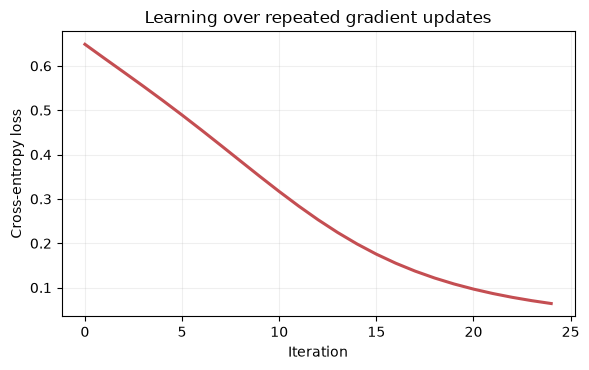

In [7]:
p_history = []
loss_history = []

for step in range(n_steps_ex):
    s_ex = e1_ex + e2_ex
    h_ex = A_ex @ s_ex
    u_ex = M_ex @ h_ex
    p_ex = softmax(u_ex)
    loss_ex = -np.log(p_ex[target_ex])

    du_ex = p_ex - y_ex
    dM_ex = np.outer(du_ex, h_ex)
    dh_ex = M_ex.T @ du_ex
    dA_ex = np.outer(dh_ex, s_ex)
    ds_ex = A_ex.T @ dh_ex

    M_ex -= eta_ex*dM_ex
    A_ex -= eta_ex*dA_ex
    e1_ex -= eta_ex*ds_ex
    e2_ex -= eta_ex*ds_ex

    p_history.append(p_ex[target_ex])
    loss_history.append(loss_ex)

assert loss_history[-1] < loss_history[0], "Final loss should be smaller than initial loss."
print(f"First target probability: {p_history[0]:.3f}")
print(f"Final target probability: {p_history[-1]:.3f}")
print(f"First loss: {loss_history[0]:.3f}")
print(f"Final loss: {loss_history[-1]:.3f}")

fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.plot(range(n_steps_ex), loss_history, color="#C44E52", linewidth=2.2)
ax.set(xlabel="Iteration", ylabel="Cross-entropy loss",
       title="Learning over repeated gradient updates")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### Rubric and hints (10 points)

- **Exercise DGP and dimensions (1 point).**  
  *Hint:* the two logits and `y_ex` must each have length 2.

- **Forward pass and loss (2 points).**  
  *Hint:* apply `softmax` to the logits and select the probability indexed by
  `target_ex` inside the negative log.

- **Backpropagation (3 points).**  
  *Hint:* the logit gradient is predicted probabilities minus the one-hot target.
  Then work backward through $M$ and $A$.

- **Parameter updates (2 points).**  
  *Hint:* update $M$ using its own gradient. Both context embeddings receive
  `ds_ex` because they were added to form `s_ex`.

- **Learning check and interpretation (2 points).**  
  *Hint:* compare the final loss with the first recorded loss. Explain why the
  next iteration must start from the updated parameters.
